In [14]:
!pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [folium]


In [29]:
!pip install contextily geopandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 13.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 14.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 12.8 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: click━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/12 [pyogrio]
    Found existing installation: click 8.2.1━━━━━━━━━━━━━━━━━━  2/12 [pyogrio]
    Uninstalling click-8.2.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/12 [pyogrio]
      Successfully uninstalled click-8.2.1━━━━━━━━━━━━━━━━━━━━  2/12 [pyogrio]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [contextily]2 [geopandas]


In [30]:
import seaborn as sns
sns.set(font_scale=2, style="white")

import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
# set plotting size parameter
plt.rcParams['figure.figsize'] = (17, 7)

# import pandas & numpy library
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.ticker as mticker
import folium
from folium.plugins import HeatMap
import re


In [31]:
mta_ny_monthly = pd.read_csv('data/MTA_Monthly_Ridership___Traffic_Data__Beginning_January_2008_20260517.csv')
mta_ny_monthly

,Month,Agency,Ridership
0,2008-01-01,MNR,"6,453,734"
1,2008-02-01,MNR,"6,144,377"
2,2008-03-01,MNR,"6,602,280"
3,2008-04-01,B&T,"24,900,328"
4,2008-04-01,MNR,"6,787,480"
...,...,...,...
973,2026-03-01,MNR,"6,098,900.600000001"
974,2026-03-01,MTA Bus,"7,534,232"
975,2026-03-01,NYCT Bus,"28,587,152"
976,2026-03-01,SIR,"220,834"


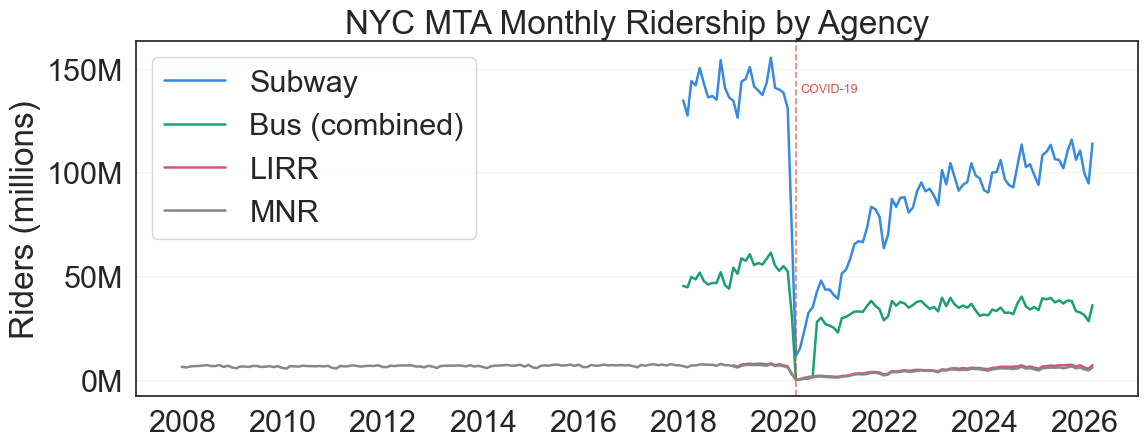

In [32]:
# Make line chart representing MTA use in NYC over time, accounting for COVID
mta_ny_monthly["Month"] = pd.to_datetime(mta_ny_monthly["Month"])
mta_ny_monthly["Ridership"] = mta_ny_monthly["Ridership"].str.replace(",", "").astype(float)


pivot = mta_ny_monthly.pivot_table(index="Month", columns="Agency", values="Ridership", aggfunc="sum")

pivot["Bus (combined)"] = pivot[["Bus", "NYCT Bus", "MTA Bus"]].sum(axis=1).replace(0, None)

agencies = {
    "Subway":         "#378ADD",
    "Bus (combined)": "#1D9E75",
    "LIRR":           "#D4537E",
    "MNR":            "#888780",
}

fig, ax = plt.subplots(figsize=(12, 5))

for agency, color in agencies.items():
    if agency in pivot.columns:
        series = pivot[agency] / 1e6  # convert to millions
        ax.plot(pivot.index, series, label=agency, color=color, linewidth=1.8)

ax.axvline(pd.Timestamp("2020-04-01"), color="#E24B4A", linestyle="--", linewidth=1.2, alpha=0.7)
ax.text(pd.Timestamp("2020-05-01"), ax.get_ylim()[1] * 0.85, "COVID-19", color="#E24B4A", fontsize=9)

ax.set_ylabel("Riders (millions)")
ax.set_title("NYC MTA Monthly Ridership by Agency")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [35]:
mta_hourly = pd.read_csv("data/MTA_Subway_Hourly_Ridership__April30_2026.csv")
mta_hourly["ridership"] = pd.to_numeric(mta_hourly["ridership"], errors="coerce")
mta_hourly["latitude"] = pd.to_numeric(mta_hourly["latitude"], errors="coerce")
mta_hourly["longitude"] = pd.to_numeric(mta_hourly["longitude"], errors="coerce")

stations = (
    mta_hourly.groupby(["station_complex", "latitude", "longitude"])
    ["ridership"].sum().reset_index()
)
stations["latitude"] = stations["latitude"].astype(float)
stations["longitude"] = stations["longitude"].astype(float)

LINE_COLORS = {
    "1": "#EE352E", "2": "#EE352E", "3": "#EE352E",
    "4": "#00933C", "5": "#00933C", "6": "#00933C",
    "7": "#B933AD",
    "A": "#0039A6", "C": "#0039A6", "E": "#0039A6",
    "B": "#FF6319", "D": "#FF6319", "F": "#FF6319", "M": "#FF6319",
    "G": "#6CBE45",
    "J": "#996633", "Z": "#996633",
    "L": "#A7A9AC",
    "N": "#FCCC0A", "Q": "#FCCC0A", "R": "#FCCC0A", "W": "#FCCC0A",
    "S": "#808183",
}

def parse_first_line(name):
    match = re.search(r'\(([^)]+)\)', name)
    if match:
        return match.group(1).split(",")[0].strip()
    return "S"

stations["color"] = stations["station_complex"].apply(
    lambda n: LINE_COLORS.get(parse_first_line(n), "#AAAAAA")
)

max_r = stations["ridership"].max()
stations["norm"] = stations["ridership"] / max_r


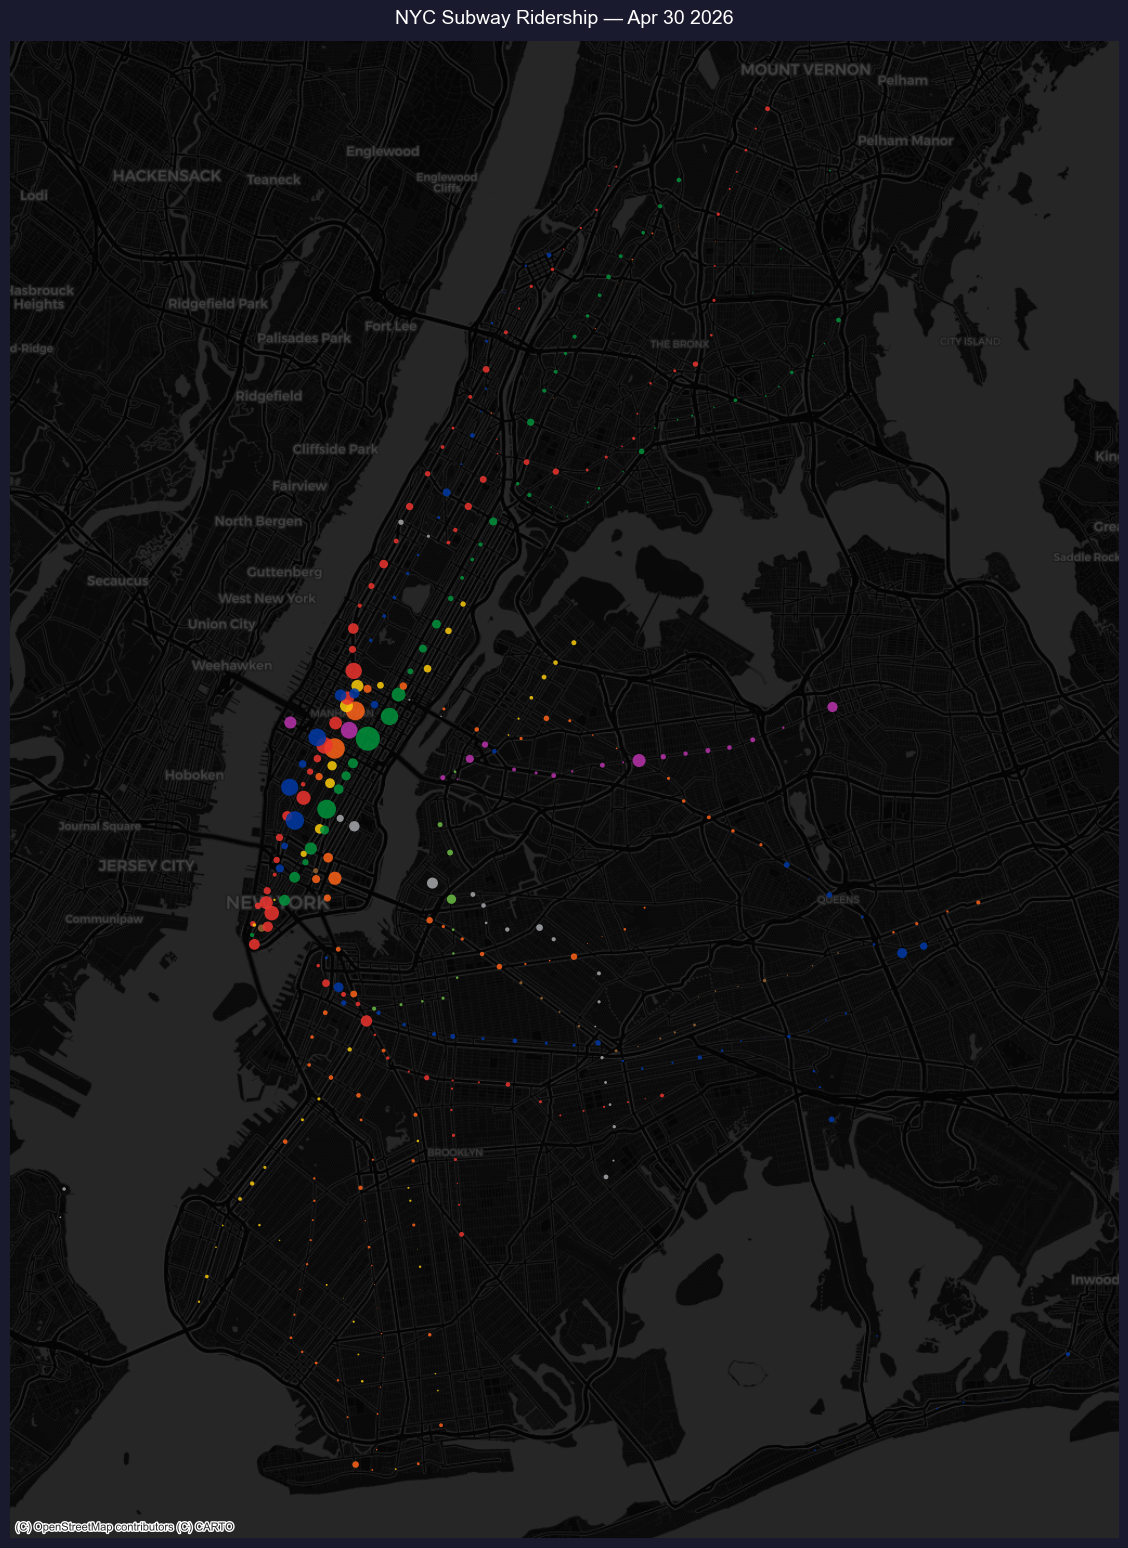

In [36]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["longitude"], stations["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 16))

gdf.plot(
    ax=ax,
    color=gdf["color"],
    markersize=gdf["norm"] * 300,
    alpha=0.85,
    linewidths=0,
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter, zoom=12)

ax.set_axis_off()
ax.set_title("NYC Subway Ridership — Apr 30 2026", color="white",
             fontsize=14, pad=12)
fig.patch.set_facecolor("#1a1a2e")
plt.tight_layout()
plt.savefig("subway_map.png", dpi=150, bbox_inches="tight")
plt.show()